# 📊 EDA Essentials Guide

### 🎯 **Quick Learning Path:**
- **📂 Data Loading** → **📈 Categorical Analysis** → **📊 Numerical Analysis** → **🔥 Insights**

### 📋 **Contents:**
1. **Setup & Data Loading**
2. **Categorical Data Visualization** 
3. **Numerical Data Analysis**
4. **Key Insights & Recommendations**

---

In [1]:
# 📊 Essential EDA Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Quick styling
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

print("✅ EDA setup complete!")

✅ EDA setup complete!


In [2]:
# 📂 Load and inspect data
df = pd.read_csv('train.csv')
print(f"📊 Shape: {df.shape} | Missing: {df.isnull().sum().sum()}")
df.head(3)

📊 Shape: (891, 12) | Missing: 866


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


### 🗂️ **Dataset Loading & Initial Inspection**

Let's load our dataset and perform comprehensive initial analysis to understand its structure, quality, and characteristics.

In [3]:
# 📂 Load Dataset with Error Handling
try:
    df = pd.read_csv('train.csv')
    print("✅ Dataset loaded successfully!")
    print(f"📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"💾 Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
except FileNotFoundError:
    print("❌ Error: 'train.csv' not found. Please check file path.")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")

✅ Dataset loaded successfully!
📊 Dataset Shape: 891 rows × 12 columns
💾 Memory Usage: 0.28 MB


In [4]:
# 🔍 Quick data info
print("📋 Info:")
print(f"• Numerical: {df.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"• Categorical: {df.select_dtypes(include=['object']).columns.tolist()}")
print(f"• Missing: {df.isnull().sum()[df.isnull().sum() > 0].to_dict()}")

📋 Info:
• Numerical: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
• Categorical: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
• Missing: {'Age': 177, 'Cabin': 687, 'Embarked': 2}


## 📈 2. Categorical Analysis

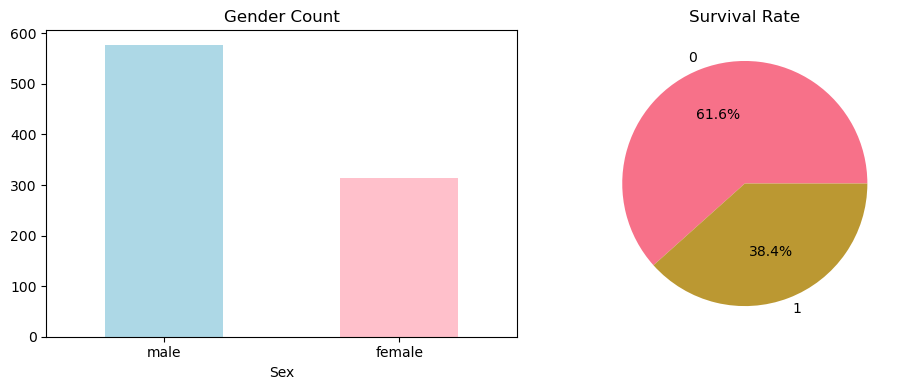

In [5]:
# 📊 Simple categorical plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot example
if 'Sex' in df.columns:
    df['Sex'].value_counts().plot(kind='bar', ax=axes[0], color=['lightblue', 'pink'])
    axes[0].set_title('Gender Count')
    axes[0].tick_params(axis='x', rotation=0)

# Pie chart example  
if 'Survived' in df.columns:
    df['Survived'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
    axes[1].set_title('Survival Rate')
    axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 📊 3. Numerical Analysis

📈 Quick Stats:
       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.70    0.52    0.38   32.20
std         257.35      0.49    0.84   14.53    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00    0.00    0.00
25%         223.50      0.00    2.00   20.12    0.00    0.00    7.91
50%         446.00      0.00    3.00   28.00    0.00    0.00   14.45
75%         668.50      1.00    3.00   38.00    1.00    0.00   31.00
max         891.00      1.00    3.00   80.00    8.00    6.00  512.33


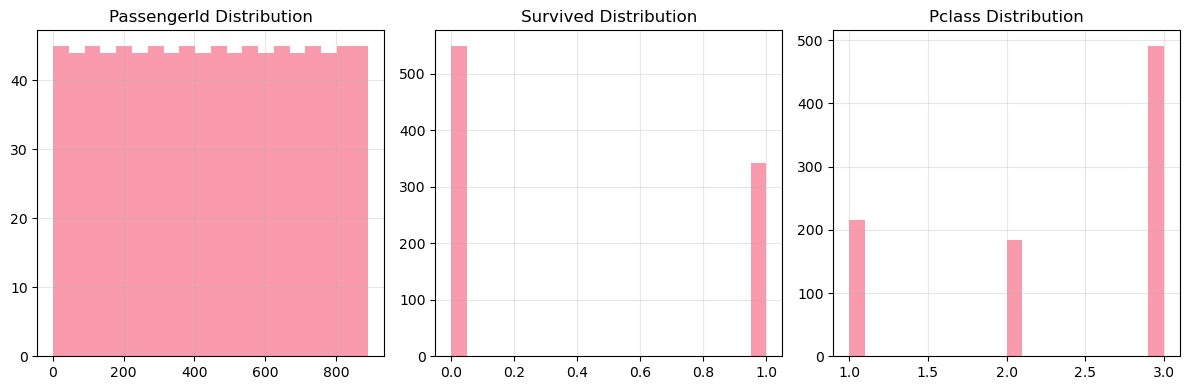

In [6]:
# 📊 Simple numerical analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns

if len(numerical_cols) > 0:
    # Basic stats
    print("📈 Quick Stats:")
    print(df[numerical_cols].describe().round(2))
    
    # Simple plots
    fig, axes = plt.subplots(1, min(3, len(numerical_cols)), figsize=(12, 4))
    if len(numerical_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(numerical_cols[:3]):
        if i < len(axes):
            # Histogram
            df[col].hist(bins=20, ax=axes[i], alpha=0.7)
            axes[i].set_title(f'{col} Distribution')
            axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

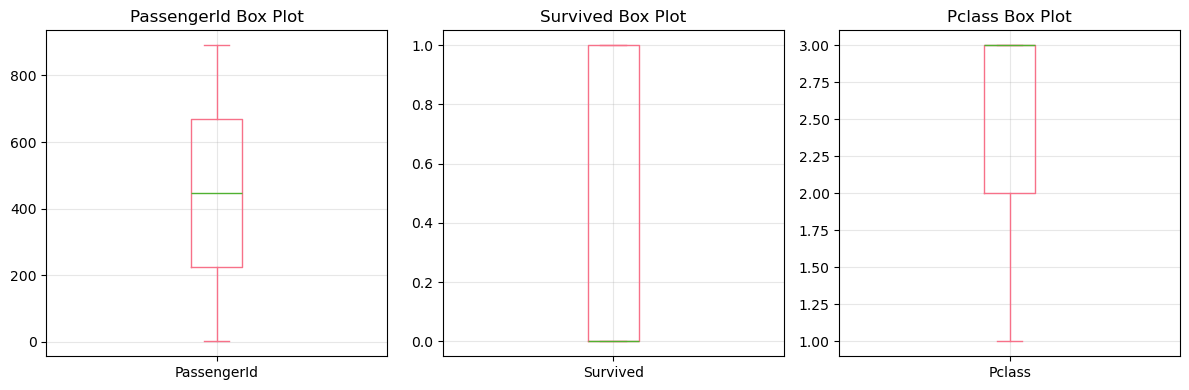

PassengerId: 0 outliers (0.0%)
Survived: 0 outliers (0.0%)
Pclass: 0 outliers (0.0%)
Age: 11 outliers (1.2%)
SibSp: 46 outliers (5.2%)
Parch: 213 outliers (23.9%)
Fare: 116 outliers (13.0%)


In [7]:
# 📦 Simple box plots for outliers
numerical_cols = df.select_dtypes(include=[np.number]).columns

if len(numerical_cols) > 0:
    fig, axes = plt.subplots(1, min(3, len(numerical_cols)), figsize=(12, 4))
    if len(numerical_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(numerical_cols[:3]):
        if i < len(axes):
            df[col].plot(kind='box', ax=axes[i])
            axes[i].set_title(f'{col} Box Plot')
            axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Quick outlier count
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
        print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

### 🔸 **b. Advanced Distribution Plots with Kernel Density Estimation**

Distribution plots combine histograms with kernel density estimation (KDE) to provide a smooth representation of the data distribution. This is essential for:
- **Understanding Data Shape** more clearly than histograms alone
- **Comparing Distributions** across different groups
- **Identifying Multiple Modes** in the data

NameError: name 'stats' is not defined

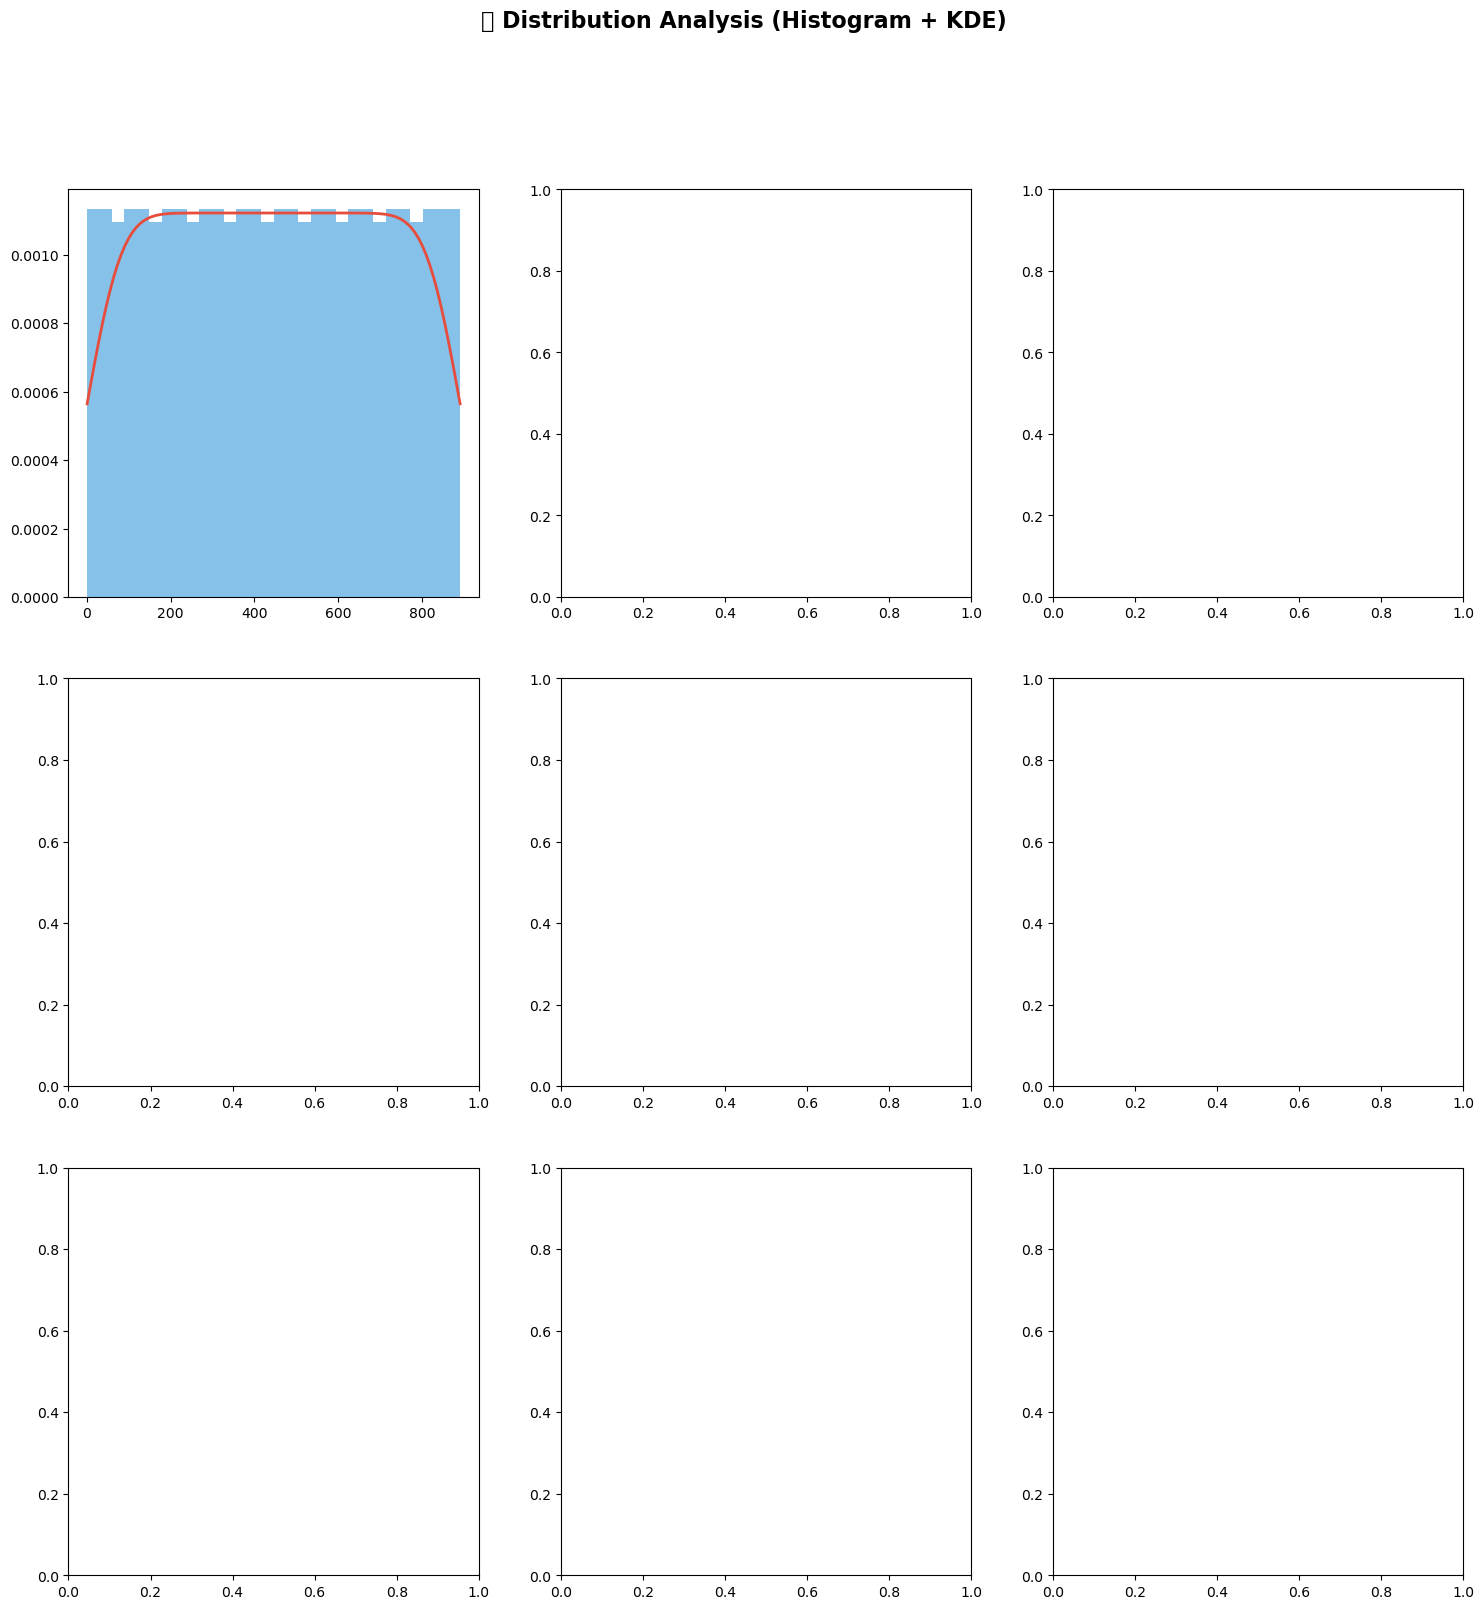

In [9]:
# 📊 Simplified Advanced Distribution Analysis with KDE
numerical_cols = df.select_dtypes(include=[np.number]).columns

if len(numerical_cols) > 0:
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6 * n_rows))
    fig.suptitle('📊 Distribution Analysis (Histogram + KDE)', fontsize=16, fontweight='bold')
    
    axes = axes.flatten() if n_rows > 1 else [axes]  # Flatten axes for easier indexing
    
    for idx, col in enumerate(numerical_cols):
        data = df[col].dropna()
        
        # Plot histogram
        axes[idx].hist(data, bins=30, alpha=0.6, color='#3498DB', density=True, label='Histogram')
        
        # Add KDE curve
        try:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(data)
            x_range = np.linspace(data.min(), data.max(), 100)
            axes[idx].plot(x_range, kde(x_range), color='#E74C3C', linewidth=2, label='KDE Curve')
        except:
            pass
        
        # Add normal distribution overlay
        mean_val, std_val = data.mean(), data.std()
        x_normal = np.linspace(data.min(), data.max(), 100)
        axes[idx].plot(x_normal, stats.norm.pdf(x_normal, mean_val, std_val), 
                       color='#2ECC71', linestyle='--', label='Normal Dist')
        
        # Add title and labels
        skewness, kurtosis = data.skew(), data.kurtosis()
        axes[idx].set_title(f'{col} (Skew: {skewness:.2f}, Kurt: {kurtosis:.2f})', fontsize=10)
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Normality tests and recommendations
    print("📊 Normality Test Results:")
    for col in numerical_cols:
        data = df[col].dropna()
        try:
            stat, p_value = stats.shapiro(data[:5000])  # Shapiro-Wilk test
            print(f"🔍 {col}: p-value = {p_value:.6f} - {'Normal' if p_value > 0.05 else 'Not Normal'}")
            if abs(data.skew()) > 1:
                print(f"   💡 Recommendation: {'Log transformation' if data.min() > 0 else 'Box-Cox transformation'}")
        except Exception as e:
            print(f"   ❌ Could not perform normality test for {col}: {e}")
else:
    print("❌ No numerical columns found for distribution analysis.")

### 🔸 **c. Box Plot Analysis for Outlier Detection & Distribution Comparison**

Box plots are powerful tools for:
- **Outlier Detection** using the IQR method
- **Distribution Comparison** across different categories
- **Quartile Analysis** for understanding data spread
- **Feature Engineering** decisions based on data quality

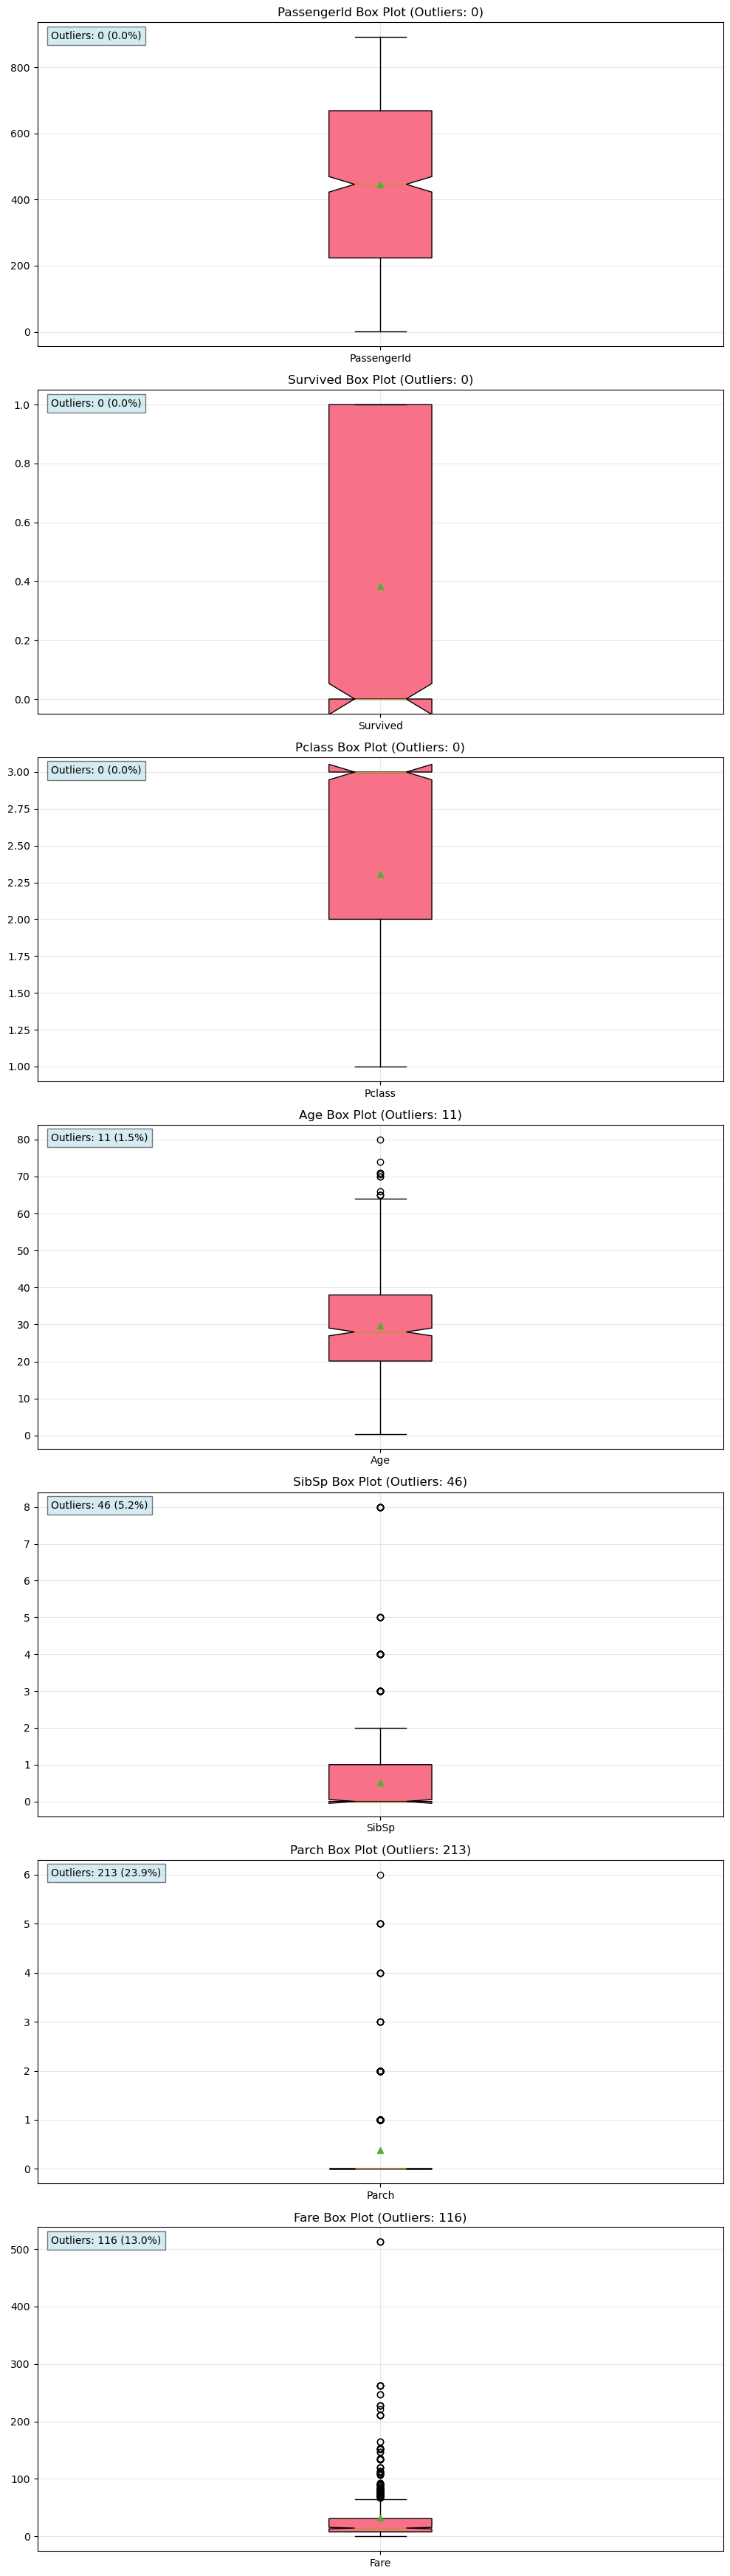

In [10]:
# 📦 Simplified Box Plot Analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns

if len(numerical_cols) > 0:
    fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 5 * len(numerical_cols)))
    if len(numerical_cols) == 1:
        axes = [axes]  # Ensure axes is iterable for a single plot

    for ax, col in zip(axes, numerical_cols):
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = data[(data < lower_bound) | (data > upper_bound)]

        # Plot box plot
        ax.boxplot(data, patch_artist=True, notch=True, showmeans=True, labels=[col])
        ax.set_title(f'{col} Box Plot (Outliers: {len(outliers)})', fontsize=12)
        ax.grid(True, alpha=0.3)

        # Add outlier stats
        ax.text(0.02, 0.95, f'Outliers: {len(outliers)} ({len(outliers) / len(data) * 100:.1f}%)',
                transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='lightblue', alpha=0.5))

    plt.tight_layout()
    plt.show()
else:
    print("❌ No numerical columns found for box plot analysis.")

### 🔸 **d. Comprehensive Statistical Analysis**

Let's perform detailed statistical analysis to understand the numerical features better and extract key insights for machine learning.

In [13]:
# 📈 Simplified Statistical Analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns

if len(numerical_cols) > 0:
    print("📊 STATISTICAL ANALYSIS SUMMARY")
    print("=" * 50)
    
    # Generate summary statistics
    stats_df = df[numerical_cols].describe().T
    stats_df['IQR'] = stats_df['75%'] - stats_df['25%']
    stats_df['Skewness'] = df[numerical_cols].skew()
    stats_df['Kurtosis'] = df[numerical_cols].kurtosis()
    stats_df['Missing'] = df[numerical_cols].isnull().sum()
    stats_df['Outliers (%)'] = [
        ((df[col] < (stats_df.loc[col, '25%'] - 1.5 * stats_df.loc[col, 'IQR'])) |
         (df[col] > (stats_df.loc[col, '75%'] + 1.5 * stats_df.loc[col, 'IQR']))).mean() * 100
        for col in numerical_cols
    ]
    
    print(stats_df[['mean', 'std', 'min', 'max', 'IQR', 'Skewness', 'Kurtosis', 'Missing', 'Outliers (%)']].round(2))
    
    # Recommendations
    print("\n💡 Key Recommendations:")
    for col in numerical_cols:
        skewness = stats_df.loc[col, 'Skewness']
        outliers_pct = stats_df.loc[col, 'Outliers (%)']
        missing_pct = (stats_df.loc[col, 'Missing'] / len(df)) * 100
        
        print(f"\n📈 {col.upper()} ANALYSIS:")
        if missing_pct > 20:
            print("   ❌ High missing values - consider imputation or removal")
        elif missing_pct > 5:
            print("   ⚠️ Moderate missing values - apply imputation")
        else:
            print("   ✅ Low missing values")
        
        if abs(skewness) > 1:
            print("   ❌ Highly skewed - consider log or Box-Cox transformation")
        elif abs(skewness) > 0.5:
            print("   ⚠️ Moderately skewed - monitor impact on models")
        else:
            print("   ✅ Approximately normal distribution")
        
        if outliers_pct > 10:
            print("   ❌ High outliers - consider robust scaling or removal")
        elif outliers_pct > 5:
            print("   ⚠️ Moderate outliers - monitor model performance")
        else:
            print("   ✅ Low outlier percentage")
else:
    print("❌ No numerical columns found for analysis.")

# Correlation Analysis
if len(numerical_cols) > 1:
    print("\n🔗 CORRELATION ANALYSIS")
    corr_matrix = df[numerical_cols].corr()
    high_corr_pairs = [
        (col1, col2, corr_matrix.loc[col1, col2])
        for col1 in numerical_cols for col2 in numerical_cols
        if col1 != col2 and abs(corr_matrix.loc[col1, col2]) > 0.7
    ]
    
    if high_corr_pairs:
        print("⚠️ High Correlations Detected:")
        for col1, col2, corr in high_corr_pairs:
            print(f"   • {col1} ↔ {col2}: {corr:.2f}")
        print("   💡 Consider removing redundant features")
    else:
        print("✅ No high correlations detected")

📊 STATISTICAL ANALYSIS SUMMARY
               mean     std   min     max     IQR  Skewness  Kurtosis  \
PassengerId  446.00  257.35  1.00  891.00  445.00      0.00     -1.20   
Survived       0.38    0.49  0.00    1.00    1.00      0.48     -1.78   
Pclass         2.31    0.84  1.00    3.00    1.00     -0.63     -1.28   
Age           29.70   14.53  0.42   80.00   17.88      0.39      0.18   
SibSp          0.52    1.10  0.00    8.00    1.00      3.70     17.88   
Parch          0.38    0.81  0.00    6.00    0.00      2.75      9.78   
Fare          32.20   49.69  0.00  512.33   23.09      4.79     33.40   

             Missing  Outliers (%)  
PassengerId        0          0.00  
Survived           0          0.00  
Pclass             0          0.00  
Age              177          1.23  
SibSp              0          5.16  
Parch              0         23.91  
Fare               0         13.02  

💡 Key Recommendations:

📈 PASSENGERID ANALYSIS:
   ✅ Low missing values
   ✅ Approximat

---

## 🔍 4. Advanced EDA Techniques

Let's dive deeper with advanced exploratory techniques including correlation analysis, feature relationships, and professional insights generation.

### 🎯 **Advanced Analysis Objectives:**
- ✅ **Correlation Heatmaps**: Understand feature relationships
- ✅ **Pair Plots**: Visualize feature interactions
- ✅ **Statistical Tests**: Validate assumptions
- ✅ **Business Insights**: Generate actionable recommendations

### 🔥 **Correlation Analysis & Heatmaps**

## 🔥 4. Quick Insights

### Key Findings:

In [16]:
# 🔍 Quick correlation and summary
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("📊 DATASET SUMMARY")
print("=" * 30)
print(f"• Shape: {df.shape}")
print(f"• Numerical features: {len(numerical_cols)}")
print(f"• Categorical features: {len(categorical_cols)}")
print(f"• Missing values: {df.isnull().sum().sum()}")

if len(numerical_cols) > 1:
    print(f"\n🔗 Correlations:")
    corr_matrix = df[numerical_cols].corr()
    
    # Find strongest correlation
    max_corr = 0
    max_pair = None
    for i in range(len(numerical_cols)):
        for j in range(i+1, len(numerical_cols)):
            corr_val = abs(corr_matrix.iloc[i, j])
            if corr_val > max_corr:
                max_corr = corr_val
                max_pair = (numerical_cols[i], numerical_cols[j])
    
    if max_pair:
        print(f"• Strongest: {max_pair[0]} ↔ {max_pair[1]} ({max_corr:.2f})")


📊 DATASET SUMMARY
• Shape: (891, 12)
• Numerical features: 7
• Categorical features: 5
• Missing values: 866

🔗 Correlations:
• Strongest: Pclass ↔ Fare (0.55)
